# Least-core sob escassez de posto: do espectro plano à *spike*

**Experimento "caso simples" gaussiano** para o jogo cooperativo de rank-budget de PCA.

Geramos `A` (m×p) com entradas i.i.d. `N(μ, σ²)`, formamos `C = AᵀA`, e observamos como
o valor do **least-core** `η*_k` (e sua versão relativa `γ_k = η*_k / v_k(N)`) se comporta
quando giramos o "botão" `μ/σ`.

> **Analogia da banda 🎸 (usada o tempo todo neste notebook).**
> Imagine `p` músicos e apenas `k` microfones para gravar.
> - A *variância* (autovalor) de uma direção = "volume/talento" daquele som.
> - `v_k(S)` = a melhor gravação total que um subgrupo `S` consegue usando `k` microfones próprios.
> - Dividir a "fama/dinheiro" `v_k(N)` da banda inteira entre os músicos = a alocação `x`.
> - **Core** = uma divisão em que *nenhum subgrupo* ganharia mais se saísse e gravasse sozinho.
> - **Core vazio** = como há menos microfones (`k`) do que "vozes independentes" (posto), *sempre*
>   existe um subgrupo que faria melhor sozinho → briga eterna, nenhuma divisão é estável.
> - **Least-core `η`** = o menor "agrado" (bônus) que você precisa prometer a *todo* subgrupo para
>   ninguém ir embora batendo a porta. **`η` pequeno = banda mais harmoniosa.**
> - A **média `μ`** = o quanto todos tocam *a mesma melodia em uníssono*. Muita unidade (`μ` alto)
>   cria uma direção dominante (**spike**); cada um na sua (`μ=0`) deixa tudo simétrico (**flat**).


## 1. Setup e funções base

Implementamos:
- `vk(C, S, k)` — o valor de uma coalizão (soma dos `min(k,|S|)` maiores autovalores de `C_SS`);
- `least_core_curve(C, ...)` — resolve o LP do least-core por **enumeração exata** das `2ᵖ−2`
  coalizões próprias não-vazias (viável porque usamos `p=8` → 254 coalizões), para todo `k`.

O LP (Eq. 3 do artigo):

$$\eta^*_k=\min_{x,\,\eta\ge 0}\ \eta \quad\text{s.a.}\quad x(N)=v_k(N),\ \ x(S)+\eta\ge v_k(S)\ \ \forall S.$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from itertools import combinations

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
rng_global = np.random.default_rng(0)

P = 8                      # nº de variáveis (pequeno => enumeração exata viável)
KS = list(range(1, P + 1)) # orçamentos de posto k = 1..8


In [2]:
def make_coalitions(p):
    """Coalizões PRÓPRIAS não-vazias S (1 <= |S| <= p-1). A grande coalizão N
    entra só na restrição de igualdade; o vazio tem valor 0."""
    coals = []
    for r in range(1, p):
        coals.extend(list(S) for S in combinations(range(p), r))
    return coals

def build_A_ub(coals, p):
    """Matriz de restrições -x(S) - eta <= -v_k(S). A parte do lado esquerdo
    (pertencimento) NAO depende de k nem de C, entao construimos uma so vez."""
    nc = len(coals)
    M = np.zeros((nc, p))
    for c, S in enumerate(coals):
        M[c, S] = 1.0
    return np.hstack([-M, -np.ones((nc, 1))])   # colunas = [x_1..x_p, eta]

COALS = make_coalitions(P)
A_UB  = build_A_ub(COALS, P)
print(f"p = {P}  ->  {len(COALS)} coalizoes proprias nao-vazias (esperado 2^p - 2 = {2**P - 2})")


p = 8  ->  254 coalizoes proprias nao-vazias (esperado 2^p - 2 = 254)


In [3]:
def least_core_curve(C, ks=KS, coals=COALS, A_ub=A_UB):
    """Retorna dict k -> (eta*, gamma=eta*/vN, vN, full_eigs_desc).
    Reaproveita a decomposicao espectral de cada submatriz entre todos os k."""
    p = C.shape[0]
    full_ev = np.sort(np.linalg.eigvalsh(C))[::-1]          # autovalores de C (desc)
    spectra = [np.sort(np.linalg.eigvalsh(C[np.ix_(S, S)]))[::-1] for S in coals]

    c = np.zeros(p + 1); c[-1] = 1.0                        # minimiza eta
    A_eq = np.concatenate([np.ones(p), [0.0]])[None, :]     # x(N) = vN
    bounds = [(None, None)] * p + [(0, None)]               # x livre, eta >= 0

    out = {}
    for k in ks:
        vN = full_ev[:k].sum()
        b_ub = np.array([-ev[:min(k, len(S))].sum() for S, ev in zip(coals, spectra)])
        res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=[vN],
                      bounds=bounds, method="highs")
        eta = float(res.fun)
        out[k] = (eta, eta / vN if vN > 0 else np.nan, vN, full_ev)
    return out

def singleton_bound_gamma(full_ev, k):
    """Cota inferior espectral de Cor. 6:  (sum_{r>k} lambda_r) / (p * vN)."""
    vN = full_ev[:k].sum()
    tail = full_ev[k:].sum()
    p = len(full_ev)
    return (tail / p) / vN if vN > 0 else np.nan


## 2. Teste de sanidade — Teorema 9 (espectro plano)

Antes de qualquer coisa, validamos o solver contra o **único caso resolvido em forma fechada**.
Para `C = λ I_p` (todos os músicos igualmente talentosos, cada um tocando algo independente — o
caso de **briga máxima e simétrica** pelos microfones), o Teorema 9 garante

$$\gamma_k = 1 - \frac{k}{p}.$$

Se o nosso LP não reproduzir isso a ~`1e-9`, há bug.

In [4]:
lam = 3.7
C_flat = lam * np.eye(P)
out = least_core_curve(C_flat)

print(f"{'k':>2} | {'gamma_k (LP)':>13} | {'1 - k/p (Teo.9)':>15} | {'erro':>10}")
print("-" * 50)
max_err = 0.0
for k in KS:
    g = out[k][1]
    teo = 1 - k / P
    err = abs(g - teo)
    max_err = max(max_err, err)
    print(f"{k:>2} | {g:>13.9f} | {teo:>15.9f} | {err:>10.2e}")
print(f"\nErro maximo = {max_err:.2e}  ->  {'OK, solver validado.' if max_err < 1e-7 else 'FALHOU!'}")


 k |  gamma_k (LP) | 1 - k/p (Teo.9) |       erro
--------------------------------------------------
 1 |   0.875000000 |     0.875000000 |   2.22e-16
 2 |   0.750000000 |     0.750000000 |   1.11e-16
 3 |   0.625000000 |     0.625000000 |   3.33e-16
 4 |   0.500000000 |     0.500000000 |   2.22e-16
 5 |   0.375000000 |     0.375000000 |   0.00e+00
 6 |   0.250000000 |     0.250000000 |   0.00e+00
 7 |   0.125000000 |     0.125000000 |   8.33e-17
 8 |   0.000000000 |     0.000000000 |   0.00e+00

Erro maximo = 3.33e-16  ->  OK, solver validado.


## 3. Gerador de dados e o que a teoria prevê

`gen_C` cria `A` (m×p) gaussiana e devolve `C = AᵀA`. **Não centralizamos** as colunas — é
justamente a média `μ` que precisa sobreviver para criar a *spike*.

Lembre a conta:
$$E[C] = \underbrace{m\sigma^2 I_p}_{\text{platô (flat)}} + \underbrace{m\mu^2\,\mathbf{1}\mathbf{1}^\top}_{\text{agulha (spike) na direção }\mathbf 1}$$

- **`μ = 0`** → `E[C] = mσ²I` → espectro plano → banda em que todos tocam coisas independentes →
  deve cair no Teorema 9 (`γ_k ≈ 1 − k/p`).
- **`μ ≫ σ`** → uma direção (o "uníssono" `1`) domina → *spike* → `γ_1` despenca.

O único botão que muda `γ_k` (que é invariante a escala) é a razão `ρ = μ²/σ²`.

In [5]:
def gen_C(m, p, mu, sigma, rng, center=False):
    A = rng.normal(mu, sigma, size=(m, p))
    if center:
        A = A - A.mean(axis=0, keepdims=True)
    return A.T @ A

def mc_gamma(m, mu, sigma, n_seeds, ks=KS, p=P, seed0=0, center=False):
    """Monte Carlo: media e desvio de gamma_k (e eta_k) sobre n_seeds matrizes C."""
    G = np.zeros((n_seeds, len(ks)))
    E = np.zeros((n_seeds, len(ks)))
    B = np.zeros((n_seeds, len(ks)))   # cota de singleton (em gamma)
    for s in range(n_seeds):
        rng = np.random.default_rng(seed0 + s)
        C = gen_C(m, p, mu, sigma, rng, center=center)
        out = least_core_curve(C)
        full_ev = out[ks[0]][3]
        for j, k in enumerate(ks):
            E[s, j] = out[k][0]
            G[s, j] = out[k][1]
            B[s, j] = singleton_bound_gamma(full_ev, k)
    return dict(g_mean=G.mean(0), g_std=G.std(0),
                e_mean=E.mean(0), e_std=E.std(0),
                b_mean=B.mean(0))

N_SEEDS = 60      # aumente para curvas mais lisas (custa tempo)
SIGMA   = 1.0     # fixo: so a razao mu/sigma importa para gamma
M_MAIN  = 64      # nº de amostras (linhas de A)
print("Funcoes de Monte Carlo prontas. N_SEEDS =", N_SEEDS)


Funcoes de Monte Carlo prontas. N_SEEDS = 60


## 4. Experimento 1 — `γ_k` vs `k`, variando `μ` (flat → spike)

Cada curva é uma "banda" com um nível de uníssono `μ` diferente (σ=1 fixo, m=64).
Esperado: a curva de `μ=0` segue a reta `1−k/p` (Teorema 9); conforme `μ` cresce, a curva
**afunda em `k` pequeno** (a *spike* é capturada já com poucos microfones) e começa a ficar
**não-monótona** — a assinatura do cenário *spike* da Tabela 1 do artigo.

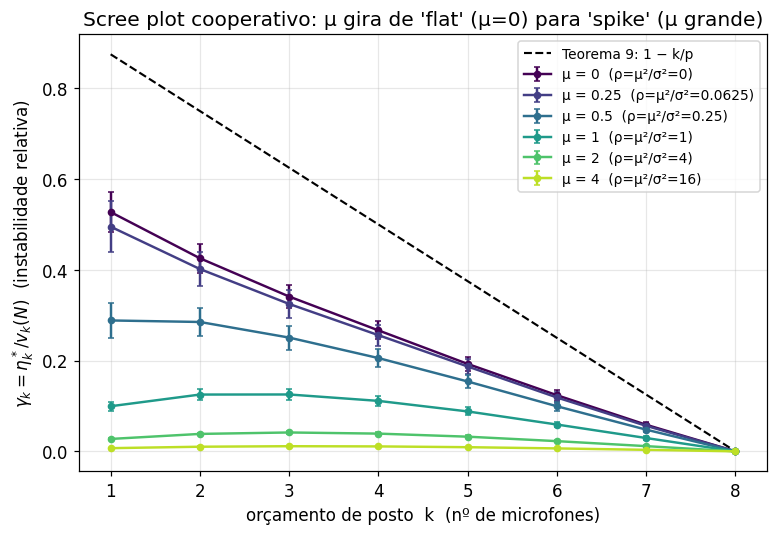

In [6]:
MUS = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]
res1 = {mu: mc_gamma(M_MAIN, mu, SIGMA, N_SEEDS) for mu in MUS}

fig, ax = plt.subplots(figsize=(7.2, 5))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(MUS)))
for mu, col in zip(MUS, colors):
    r = res1[mu]
    ax.errorbar(KS, r["g_mean"], yerr=r["g_std"], color=col, marker="o",
                ms=4, capsize=2, lw=1.6, label=f"μ = {mu:g}  (ρ=μ²/σ²={mu**2:g})")
ax.plot(KS, [1 - k / P for k in KS], "k--", lw=1.4, label="Teorema 9: 1 − k/p")
ax.set_xlabel("orçamento de posto  k  (nº de microfones)")
ax.set_ylabel(r"$\gamma_k = \eta^*_k / v_k(N)$  (instabilidade relativa)")
ax.set_title("Scree plot cooperativo: μ gira de 'flat' (μ=0) para 'spike' (μ grande)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Leitura 🎸:** em `μ=0` ninguém toca junto → todos brigam igualmente pelos microfones →
instabilidade alta e simétrica (segue a reta tracejada). Quando `μ` sobe, surge uma melodia
comum (a *spike*): o primeiro microfone já grava quase tudo que importa, então a briga pelo
`k=1` quase some (`γ_1` despenca) — mas microfones intermediários podem reativar conflito sobre
as direções de ruído, gerando a corcova não-monótona.

## 5. Experimento 2 — colapso de `γ_1` e `η*_1` vs o botão `μ/σ`

Aqui isolamos `k=1` (um único microfone) e varremos `μ/σ` finamente. É a "curva de colapso":
quão rápido a instabilidade do *singleton* some quando a *spike* aparece.
Mostramos `γ_1` (relativo, invariante a escala) e `η*_1` (absoluto, cresce com a energia total).

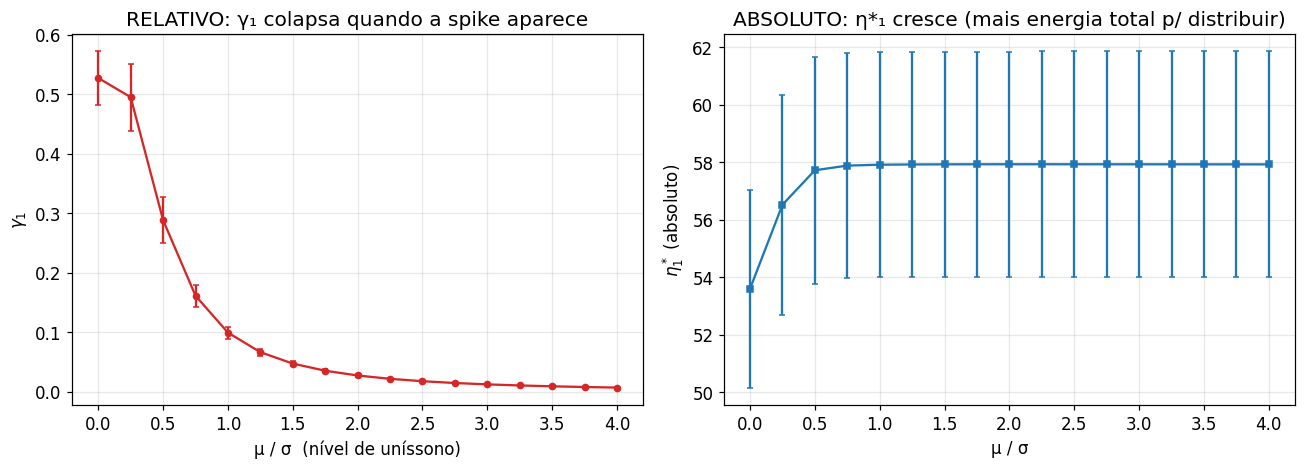

In [7]:
MU_GRID = np.round(np.linspace(0, 4, 17), 3)
g1, g1s, e1, e1s = [], [], [], []
# guardamos tambem a curva completa gamma_k(mu) para o heatmap (Exp 3)
heat = np.zeros((len(MU_GRID), len(KS)))
for i, mu in enumerate(MU_GRID):
    r = mc_gamma(M_MAIN, mu, SIGMA, N_SEEDS)
    g1.append(r["g_mean"][0]); g1s.append(r["g_std"][0])
    e1.append(r["e_mean"][0]); e1s.append(r["e_std"][0])
    heat[i] = r["g_mean"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].errorbar(MU_GRID, g1, yerr=g1s, marker="o", ms=4, capsize=2, color="C3")
axes[0].set_xlabel("μ / σ  (nível de uníssono)"); axes[0].set_ylabel(r"$\gamma_1$")
axes[0].set_title("RELATIVO: γ₁ colapsa quando a spike aparece"); axes[0].grid(alpha=0.3)

axes[1].errorbar(MU_GRID, e1, yerr=e1s, marker="s", ms=4, capsize=2, color="C0")
axes[1].set_xlabel("μ / σ"); axes[1].set_ylabel(r"$\eta^*_1$ (absoluto)")
axes[1].set_title("ABSOLUTO: η*₁ cresce (mais energia total p/ distribuir)"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Leitura:** o painel da esquerda (relativo) mostra a *instabilidade* sumindo — a banda fica
harmoniosa porque há um líder claro. O da direita (absoluto) **sobe**, mas isso é só porque a banda
ficou "mais alta" no total (`μ` injeta energia em `C`): por isso o artigo insiste em normalizar e
olhar `γ`, não `η` cru.

## 6. Experimento 3 — mapa de calor `γ_k` sobre `(k, μ/σ)`

Visão global da transição flat→spike: cada coluna é uma curva do Experimento 1.

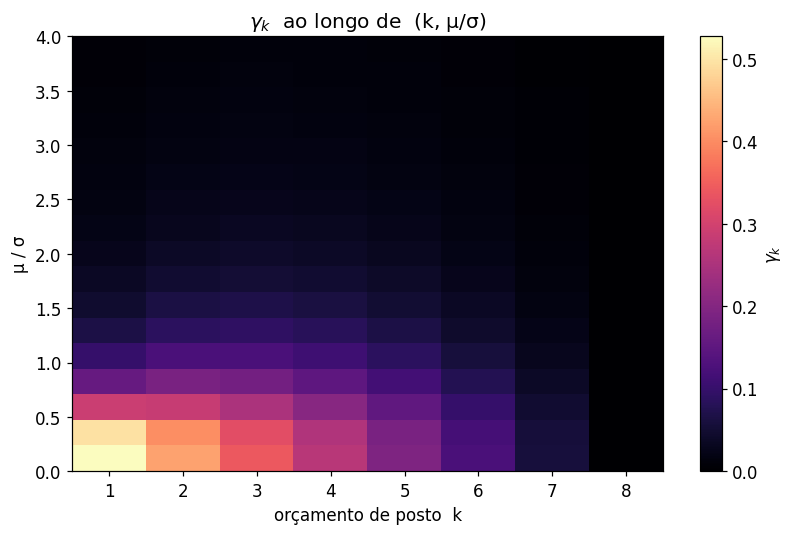

In [8]:
fig, ax = plt.subplots(figsize=(7.6, 5))
im = ax.imshow(heat, aspect="auto", origin="lower", cmap="magma",
               extent=[KS[0]-0.5, KS[-1]+0.5, MU_GRID[0], MU_GRID[-1]])
ax.set_xlabel("orçamento de posto  k"); ax.set_ylabel("μ / σ")
ax.set_title(r"$\gamma_k$  ao longo de  (k, μ/σ)")
cb = plt.colorbar(im, ax=ax); cb.set_label(r"$\gamma_k$")
ax.set_xticks(KS)
plt.tight_layout(); plt.show()


**Leitura:** a faixa quente (instável) vive embaixo (`μ≈0`, espectro plano) e à esquerda
(`k` pequeno). Subindo `μ`, a banda esfria — especialmente para `k=1`, onde um único microfone já
captura a melodia comum.

## 7. Experimento 4 — convergência ao Teorema 9 quando `m` cresce (`μ=0`)

Com `μ=0`, `C` é uma matriz de Wishart: só *em média* é plana. Para `m` finito há flutuações
(o "bulk" de Marchenko–Pastur). Aumentando `m`, `C/m → σ²I` e `γ_k → 1 − k/p`. Medimos o erro.

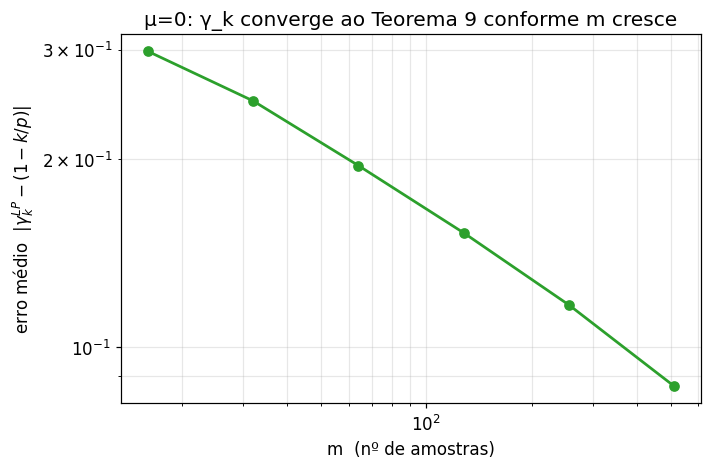

erros: ['0.2982', '0.2483', '0.1956', '0.1526', '0.1169', '0.0866']


In [9]:
MS = [16, 32, 64, 128, 256, 512]
teo = np.array([1 - k / P for k in KS])
errs = []
for m in MS:
    r = mc_gamma(m, 0.0, SIGMA, N_SEEDS)
    errs.append(np.abs(r["g_mean"] - teo).mean())

fig, ax = plt.subplots(figsize=(6.6, 4.4))
ax.loglog(MS, errs, "o-", color="C2", lw=1.8)
ax.set_xlabel("m  (nº de amostras)")
ax.set_ylabel(r"erro médio  $|\gamma_k^{LP} - (1-k/p)|$")
ax.set_title("μ=0: γ_k converge ao Teorema 9 conforme m cresce")
ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
print("erros:", [f"{e:.4f}" for e in errs])


## 8. Experimento 5 — `γ_k` vs a cota de singleton (excesso coalizional)

A **cota de singleton** (Corolário 6) é tudo que o espectro *global* sozinho consegue prever da
instabilidade. A diferença `γ_k − cota` é o **excesso estritamente coalizional**: instabilidade que
*não* se vê nos autovalores, só na forma como as variáveis se agrupam. 🎸 É a parte da briga que
só existe por causa de *quem se junta com quem*, não do talento individual.

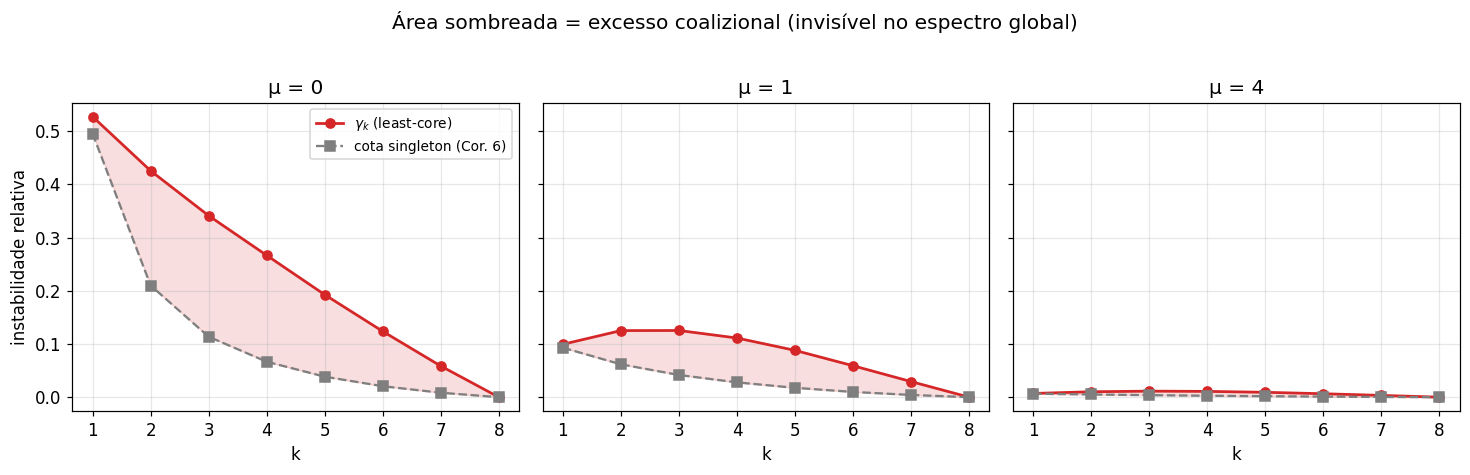

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)
for ax, mu in zip(axes, [0.0, 1.0, 4.0]):
    r = res1[mu] if mu in res1 else mc_gamma(M_MAIN, mu, SIGMA, N_SEEDS)
    ax.plot(KS, r["g_mean"], "o-", color="C3", lw=1.8, label=r"$\gamma_k$ (least-core)")
    ax.plot(KS, r["b_mean"], "s--", color="C7", lw=1.5, label="cota singleton (Cor. 6)")
    ax.fill_between(KS, r["b_mean"], r["g_mean"], color="C3", alpha=0.15)
    ax.set_title(f"μ = {mu:g}"); ax.set_xlabel("k"); ax.grid(alpha=0.3)
axes[0].set_ylabel(r"instabilidade relativa"); axes[0].legend(fontsize=9)
fig.suptitle("Área sombreada = excesso coalizional (invisível no espectro global)", y=1.02)
plt.tight_layout(); plt.show()


**Leitura:** em `μ=0` (flat, simétrico) a cota encosta em `γ_k` — o espectro global já conta a
história toda. Com `μ` crescendo e estrutura aparecendo, abre-se uma área sombreada: o least-core
"vê" conflito que o scree plot clássico não vê.

## 9. Controle — invariância de escala de `γ`

`η*_k` escala com a energia (`m`, `σ²`); `γ_k` **não** deve mudar se mantivermos `μ/σ` fixo.
Bom teste final de consistência (e da Proposição de invariância do artigo).

In [11]:
ratio = 1.5  # mu/sigma fixo
print(f"{'sigma':>6} | {'mu':>5} | gamma_k ...")
print("-" * 70)
ref = None
for sigma in [0.5, 1.0, 2.0, 4.0]:
    mu = ratio * sigma
    r = mc_gamma(M_MAIN, mu, sigma, N_SEEDS)
    g = r["g_mean"]
    print(f"{sigma:>6.2f} | {mu:>5.2f} | " + "  ".join(f"{x:.3f}" for x in g))
    if ref is None:
        ref = g
    else:
        print(f"{'':>6} | {'':>5} |  (max |Δ| vs 1ª linha = {np.abs(g - ref).max():.4f})")
print("\n-> gamma_k essencialmente constante: confirma invariancia de escala.")


 sigma |    mu | gamma_k ...
----------------------------------------------------------------------


  0.50 |  0.75 | 0.047  0.064  0.068  0.063  0.051  0.035  0.018  0.000


  1.00 |  1.50 | 0.047  0.064  0.068  0.063  0.051  0.035  0.018  0.000
       |       |  (max |Δ| vs 1ª linha = 0.0000)


  2.00 |  3.00 | 0.047  0.064  0.068  0.063  0.051  0.035  0.018  0.000
       |       |  (max |Δ| vs 1ª linha = 0.0000)


  4.00 |  6.00 | 0.047  0.064  0.068  0.063  0.051  0.035  0.018  0.000
       |       |  (max |Δ| vs 1ª linha = 0.0000)

-> gamma_k essencialmente constante: confirma invariancia de escala.


## 10. Experimento A — *quem* está brigando? (coalizões ativas no dual)

Até aqui medimos *quanta* instabilidade existe (o número `γ_k`). Agora perguntamos **quem a
causa**: quais grupos de variáveis competem pelos microfones.

Isso vem do **dual** do least-core (Teorema 7). Resolver o LP entrega, de brinde, um peso
`y_S ≥ 0` para cada coalizão. As coalizões com `y_S > 0` são as **ativas** — exatamente os
grupos que *certificam* o conflito. (Tecnicamente, `y_S` são os multiplicadores de Lagrange das
restrições; pegamos `y_S = −marginal` da restrição de `S`.)

> 🎸 Em vez de só dizer *"a banda está 30% instável"*, apontamos o dedo: **"são as coalizões de
> tamanho tal que estão se estranhando"**. No caso plano (μ=0), a teoria (prova do Teorema 9)
> diz que quem trava a estabilidade são as coalizões de tamanho **exatamente `k`** — então o peso
> dual deve se concentrar na linha `|S| = k`. Vamos ver isso e como a *spike* (μ crescente)
> reorganiza esses grupos.

**O que plotamos:** para cada `μ`, somamos o peso dual por **tamanho de coalizão** `|S|` e
mostramos num mapa de calor (eixo y = tamanho, eixo x = μ/σ). Como o modelo gaussiano é simétrico
sob permutar variáveis, *nenhuma* variável individual é especial após a média de Monte Carlo — por
isso olhamos o **tamanho** dos grupos ativos, que é a quantidade interpretável e estável.

In [12]:
def coalition_spectra(C, coals=COALS):
    """Autovalores (desc) de cada submatriz C_SS, computados uma unica vez por C."""
    return [np.sort(np.linalg.eigvalsh(C[np.ix_(S, S)]))[::-1] for S in coals]

def solve_least_core(vF, vN, p=P, A_ub=A_UB):
    """LP do least-core para QUALQUER jogo: recebe os valores v(S) (array, na ordem de COALS)
    e v(N). Retorna (eta*, resultado_do_linprog com duais)."""
    c = np.zeros(p + 1); c[-1] = 1.0
    A_eq = np.concatenate([np.ones(p), [0.0]])[None, :]
    bounds = [(None, None)] * p + [(0, None)]
    res = linprog(c, A_ub=A_ub, b_ub=-np.asarray(vF), A_eq=A_eq, b_eq=[vN],
                  bounds=bounds, method="highs")
    return float(res.fun), res

def dual_weights_vk(C, k, coals=COALS):
    """Pesos duais y_S do least-core do jogo de rank-budget v_k."""
    full_ev = np.sort(np.linalg.eigvalsh(C))[::-1]
    vN = full_ev[:k].sum()
    spectra = coalition_spectra(C, coals)
    vF = np.array([ev[:min(k, len(S))].sum() for S, ev in zip(coals, spectra)])
    _, res = solve_least_core(vF, vN)
    return -np.asarray(res.ineqlin.marginals)        # y_S >= 0

def weight_by_size(y, coals=COALS, p=P, tol=1e-9):
    w = np.zeros(p)                                  # w[q] = peso total em coalizoes de tamanho q
    for i, S in enumerate(coals):
        if y[i] > tol:
            w[len(S)] += y[i]
    return w[1:p]                                    # tamanhos 1..p-1


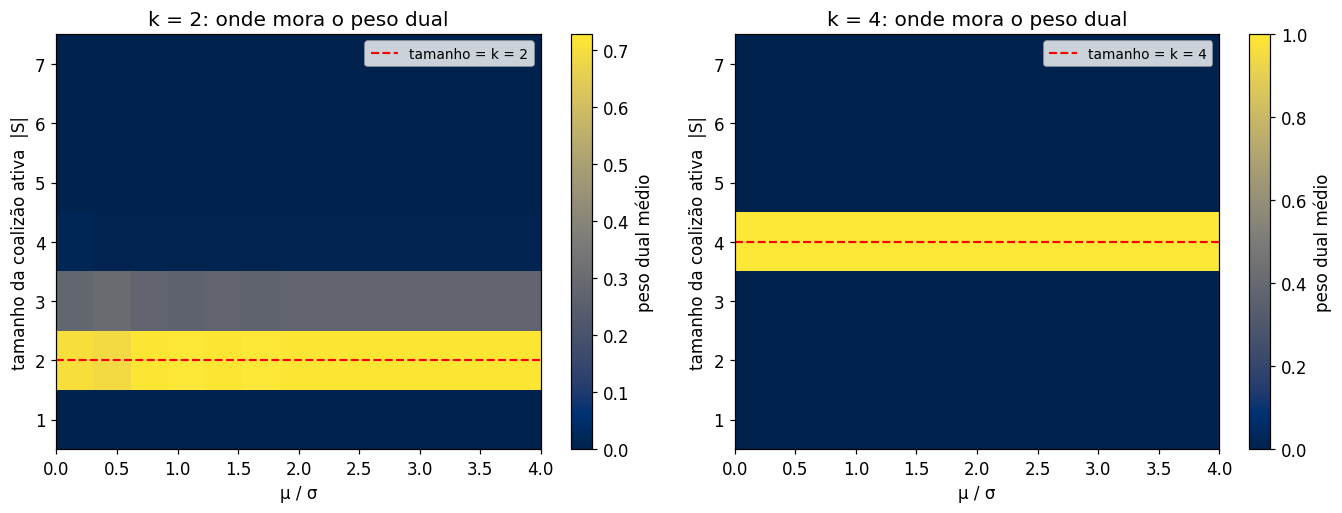

In [13]:
KS_A  = [2, 4]                                    # dois orcamentos para contraste
MU_A  = np.round(np.linspace(0, 4, 13), 3)
SIZES = np.arange(1, P)                           # 1..7
WA = {k: np.zeros((len(MU_A), len(SIZES))) for k in KS_A}

for k in KS_A:
    for i, mu in enumerate(MU_A):
        acc = np.zeros(len(SIZES))
        for s in range(N_SEEDS):
            rng = np.random.default_rng(1000 + s)
            C = gen_C(M_MAIN, P, mu, SIGMA, rng)
            acc += weight_by_size(dual_weights_vk(C, k))
        WA[k][i] = acc / N_SEEDS

fig, axes = plt.subplots(1, len(KS_A), figsize=(12.5, 4.8))
for ax, k in zip(axes, KS_A):
    im = ax.imshow(WA[k].T, aspect="auto", origin="lower", cmap="cividis",
                   extent=[MU_A[0], MU_A[-1], SIZES[0] - 0.5, SIZES[-1] + 0.5])
    ax.axhline(k, color="red", ls="--", lw=1.4, label=f"tamanho = k = {k}")
    ax.set_xlabel("μ / σ"); ax.set_ylabel("tamanho da coalizão ativa  |S|")
    ax.set_title(f"k = {k}: onde mora o peso dual")
    ax.set_yticks(SIZES); ax.legend(fontsize=9, loc="upper right")
    plt.colorbar(im, ax=ax, label="peso dual médio")
plt.tight_layout(); plt.show()


**Leitura 🎸:** em `μ=0` (esquerda de cada painel) o peso dual gruda na linha vermelha
`|S| = k` — confirma a previsão do Teorema 9 de que as coalizões de tamanho `k` são as que travam
a banda. Conforme `μ` cresce e a *spike* aparece, o peso **migra para outros tamanhos** (tipicamente
para coalizões menores): com um líder claro, o conflito deixa de ser "todo grupo de tamanho k" e
passa a se concentrar em poucos grupos. É a reorganização do conflito causada pela melodia comum.

## 11. Experimento B — a banda saudável de referência (jogo log-determinante)

O artigo usa um segundo jogo como **controle**:

$$g_\tau(S) = \log\det\!\big(I + \tau^{-1} C_{SS}\big) = \sum_r \log\!\big(1 + \mu_r(S)/\tau\big).$$

Diferente de `v_k`, ele **usa todos os modos espectrais** (com peso logarítmico, não só os `k`
maiores) e é **submodular** — a propriedade "boa" que `v_k` não tem. É o regime *regularizado*,
contra o qual a PCA truncada (regime *singular*) é comparada.

> 🎸 Pense em `g_τ` como uma **banda saudável de referência**: todos os microfones disponíveis,
> sem escassez artificial. Serve para enxergar, por contraste, o quanto a truncagem de posto de
> `v_k` é patológica. O parâmetro `τ` é um botão: `τ → ∞` deixa `g_τ` praticamente *modular*
> (cada um leva exatamente seu volume `C_ii`, banda perfeitamente estável, `γ ≈ 0`); `τ → 0` o
> empurra para `log det`, mais singular.

Fazemos duas coisas:
- **B1 — submodularidade na prática:** contamos quantas vezes a desigualdade submodular
  `v(S)+v(T) ≥ v(S∪T)+v(S∩T)` é **violada**, para `v_1` (deve violar — Prop. 3 do artigo) e para
  `g_τ` (não deve violar nunca).
- **B2 — estabilidade comparada:** o `γ` do least-core de `g_τ` (para vários `τ`) ao lado do `γ`
  de `v_k`, variando `μ`. Esperado: `g_τ` é a curva calma; `v_k` é a espinhada.

In [14]:
# ---- B1: contagem de violacoes da desigualdade submodular ----
def vk_value(C, S, k):
    if len(S) == 0: return 0.0
    ev = np.sort(np.linalg.eigvalsh(C[np.ix_(S, S)]))[::-1]
    return ev[:min(k, len(S))].sum()

def gtau_value(C, S, tau):
    if len(S) == 0: return 0.0
    ev = np.linalg.eigvalsh(C[np.ix_(S, S)])
    return float(np.sum(np.log1p(ev / tau)))

def count_submod_violations(value_fn, C, n_pairs, rng, p=P, tol=1e-9):
    """Submodular exige v(S)+v(T) >= v(S∪T)+v(S∩T). Conta violacoes (lhs < rhs)."""
    viol = 0
    for _ in range(n_pairs):
        a = rng.random(p) < 0.5
        b = rng.random(p) < 0.5
        S  = list(np.where(a)[0]);      T  = list(np.where(b)[0])
        SU = list(np.where(a | b)[0]);  SI = list(np.where(a & b)[0])
        lhs = value_fn(C, S) + value_fn(C, T)
        rhs = value_fn(C, SU) + value_fn(C, SI)
        if lhs < rhs - tol:
            viol += 1
    return viol

rng = np.random.default_rng(7)
C_test = gen_C(M_MAIN, P, 1.0, SIGMA, rng)          # uma matriz representativa (com spike leve)
n_pairs = 5000
v_viol = count_submod_violations(lambda C, S: vk_value(C, S, 1), C_test, n_pairs, np.random.default_rng(1))
g_viol = count_submod_violations(lambda C, S: gtau_value(C, S, 1.0), C_test, n_pairs, np.random.default_rng(1))
print(f"Violacoes da desigualdade submodular em {n_pairs} pares (S,T) aleatorios:")
print(f"  v_1  (rank-budget, k=1) : {v_viol:5d}   -> NAO e submodular (esperado, Prop. 3)")
print(f"  g_tau (log-determinante): {g_viol:5d}   -> submodular (0 violacoes esperadas)")


Violacoes da desigualdade submodular em 5000 pares (S,T) aleatorios:
  v_1  (rank-budget, k=1) :  1729   -> NAO e submodular (esperado, Prop. 3)
  g_tau (log-determinante):     0   -> submodular (0 violacoes esperadas)


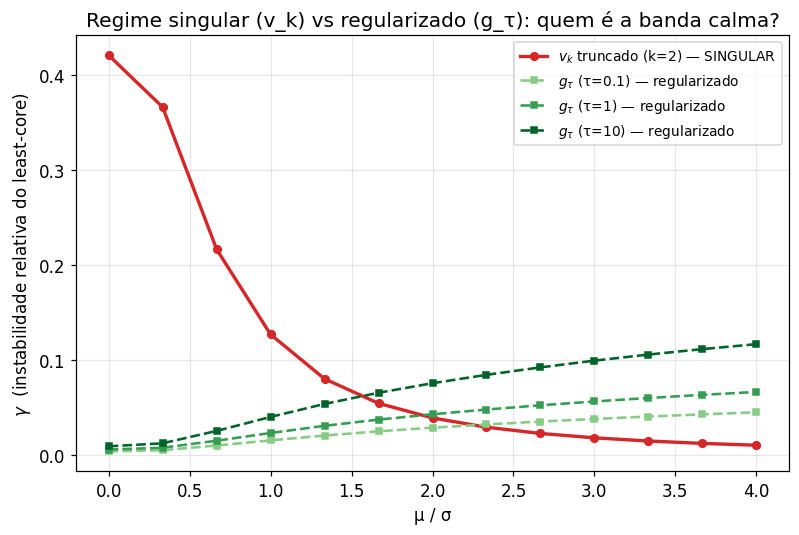

In [15]:
# ---- B2: estabilidade comparada  v_k (singular)  vs  g_tau (regularizado) ----
def gamma_gtau(C, tau, coals=COALS):
    vN = float(np.sum(np.log1p(np.linalg.eigvalsh(C) / tau)))
    spectra = coalition_spectra(C, coals)
    vF = np.array([np.sum(np.log1p(ev / tau)) for ev in spectra])
    eta, _ = solve_least_core(vF, vN)
    return eta / vN if vN > 0 else np.nan

def gamma_vk(C, k, coals=COALS):
    full_ev = np.sort(np.linalg.eigvalsh(C))[::-1]
    vN = full_ev[:k].sum()
    spectra = coalition_spectra(C, coals)
    vF = np.array([ev[:min(k, len(S))].sum() for S, ev in zip(coals, spectra)])
    eta, _ = solve_least_core(vF, vN)
    return eta / vN if vN > 0 else np.nan

TAUS  = [0.1, 1.0, 10.0]
K_REF = 2
MU_B  = np.round(np.linspace(0, 4, 13), 3)
gv = []
gg = {t: [] for t in TAUS}
for mu in MU_B:
    av = 0.0; ag = {t: 0.0 for t in TAUS}
    for s in range(N_SEEDS):
        rng = np.random.default_rng(2000 + s)
        C = gen_C(M_MAIN, P, mu, SIGMA, rng)
        av += gamma_vk(C, K_REF)
        for t in TAUS:
            ag[t] += gamma_gtau(C, t)
    gv.append(av / N_SEEDS)
    for t in TAUS:
        gg[t].append(ag[t] / N_SEEDS)

fig, ax = plt.subplots(figsize=(7.4, 5))
ax.plot(MU_B, gv, "o-", color="C3", lw=2.2, ms=5, label=f"$v_k$ truncado (k={K_REF}) — SINGULAR")
greens = plt.cm.Greens(np.linspace(0.45, 0.9, len(TAUS)))
for t, col in zip(TAUS, greens):
    ax.plot(MU_B, gg[t], "s--", color=col, lw=1.7, ms=4, label=fr"$g_\tau$ (τ={t:g}) — regularizado")
ax.set_xlabel("μ / σ"); ax.set_ylabel(r"$\gamma$  (instabilidade relativa do least-core)")
ax.set_title("Regime singular (v_k) vs regularizado (g_τ): quem é a banda calma?")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Leitura 🎸:** a curva vermelha (`v_k`, truncado) fica **bem acima** — é a banda em escassez,
sempre instável. As curvas verdes (`g_τ`) são mais calmas, e quanto **maior `τ`** mais perto de zero
(`τ` grande ⇒ `g_τ` quase modular ⇒ core quase cheio ⇒ banda estável). É a tese central do artigo,
agora visível nos seus dados: **truncar o posto (`v_k`) cria instabilidade que a regularização
(`g_τ`) não tem.** O `B1` reforça a raiz disso: `v_k` quebra a submodularidade; `g_τ` a respeita.

## 12. Conclusões do experimento

1. **`μ/σ` é o botão flat→spike.** Reproduzimos continuamente, com um único parâmetro, os dois
   cenários extremos da Tabela 1 do artigo (flat e spike).
2. **`γ_1` colapsa** quando a *spike* surge: um líder claro (a direção de uníssono `1`) torna a
   banda harmoniosa para um microfone.
3. **Não-monotonicidade** de `γ_k` aparece no regime intermediário — fenômeno estritamente
   coalizional, ausente da cauda espectral clássica.
4. **Excesso coalizional** (γ_k − cota de singleton) cresce com a estrutura: o least-core enxerga
   instabilidade invisível ao espectro global.
5. **(Exp. A) Quem briga:** o peso dual gruda no tamanho `|S| = k` no caso plano (Teorema 9) e
   migra conforme a *spike* cresce — o least-core não só mede, mas **localiza** o conflito.
6. **(Exp. B) Regime singular vs regularizado:** `v_k` viola submodularidade e é instável; o jogo
   log-determinante `g_τ` a respeita e é a banda calma de referência (mais ainda com `τ` grande).
7. **Ponte com o EigenGame:** no regime em que o EigenGame é mais *estável* (spike forte = gap
   espectral grande), o jogo cooperativo é menos *instável* (γ menor). As duas leituras concordam
   quantitativamente.

> **Próximo passo sugerido:** trocar a enumeração exata (limitada a `p≈20`) pelo oráculo
> diferenciável via EigenGame restrito (Seção 9.3 do artigo) para escalar a `p` grande.
